# Crop Disease Detection — Training
Fine-tuning EfficientNet-B2 on PlantVillage dataset.

In [1]:
import os
import json
import random
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import random_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

Using: cuda


In [15]:
DATA_DIR   = Path(r"data\PlantVillage") 
MODEL_DIR  = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 32
EPOCHS     = 15
LR         = 1e-3
IMG_SIZE   = 224
SEED       = 42

random.seed(SEED)
torch.manual_seed(SEED)
print("Config set")

Config set


In [3]:
class PlantDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir  = Path(data_dir)
        self.transform = transform
        self.classes   = sorted([d.name for d in self.data_dir.iterdir() if d.is_dir()])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            for img_path in (self.data_dir / cls).glob("*.jpg"):
                self.samples.append((img_path, self.class_to_idx[cls]))
            for img_path in (self.data_dir / cls).glob("*.JPG"):
                self.samples.append((img_path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

print("Dataset class defined")


Dataset class defined


In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Transforms defined")

Transforms defined


In [5]:
# Load full dataset first without transforms
full_dataset = PlantDataset(DATA_DIR, transform=None)
NUM_CLASSES  = len(full_dataset.classes)

# Save class names for inference later
with open(MODEL_DIR / "class_names.json", "w") as f:
    json.dump(full_dataset.classes, f)

# Split sizes
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply transforms to each split
train_set.dataset.transform = train_transform
val_set.dataset.transform   = val_transform
test_set.dataset.transform  = val_transform

print(f"Classes : {NUM_CLASSES}")
print(f"Train   : {len(train_set):,}")
print(f"Val     : {len(val_set):,}")
print(f"Test    : {len(test_set):,}")

Classes : 16
Train   : 33,017
Val     : 4,127
Test    : 4,128


In [6]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")


Train batches : 1032
Val batches   : 129


In [7]:
model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head — this is the only part we train initially
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params    : 7,723,538
Trainable params: 22,544


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LR, weight_decay=1e-4)

# Reduce LR when val loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

print("Loss, optimizer, scheduler ready")


Loss, optimizer, scheduler ready


In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

print("Functions defined")


Functions defined


In [10]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_acc": val_acc,
            "num_classes": NUM_CLASSES,
        }, MODEL_DIR / "best_model.pth")
        print(f"  --> Saved best model (val_acc={val_acc:.4f})")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Epoch 01/15 | Train Loss: 0.6767 | Train Acc: 0.8186 | Val Loss: 0.3013 | Val Acc: 0.9152
  --> Saved best model (val_acc=0.9152)
Epoch 02/15 | Train Loss: 0.3746 | Train Acc: 0.8832 | Val Loss: 0.2294 | Val Acc: 0.9324
  --> Saved best model (val_acc=0.9324)
Epoch 03/15 | Train Loss: 0.3289 | Train Acc: 0.8935 | Val Loss: 0.1941 | Val Acc: 0.9385
  --> Saved best model (val_acc=0.9385)
Epoch 04/15 | Train Loss: 0.3167 | Train Acc: 0.8951 | Val Loss: 0.1794 | Val Acc: 0.9409
  --> Saved best model (val_acc=0.9409)
Epoch 05/15 | Train Loss: 0.3036 | Train Acc: 0.8995 | Val Loss: 0.1697 | Val Acc: 0.9450
  --> Saved best model (val_acc=0.9450)
Epoch 06/15 | Train Loss: 0.2895 | Train Acc: 0.9031 | Val Loss: 0.1590 | Val Acc: 0.9465
  --> Saved best model (val_acc=0.9465)
Epoch 07/15 | Train Loss: 0.2895 | Train Acc: 0.9033 | Val Loss: 0.1601 | Val Acc: 0.9469
  --> Saved best model (val_acc=0.9469)
Epoch 08/15 | Train Loss: 0.2855 | Train Acc: 0.9020 | Val Loss: 0.1547 | Val Acc: 0.9462


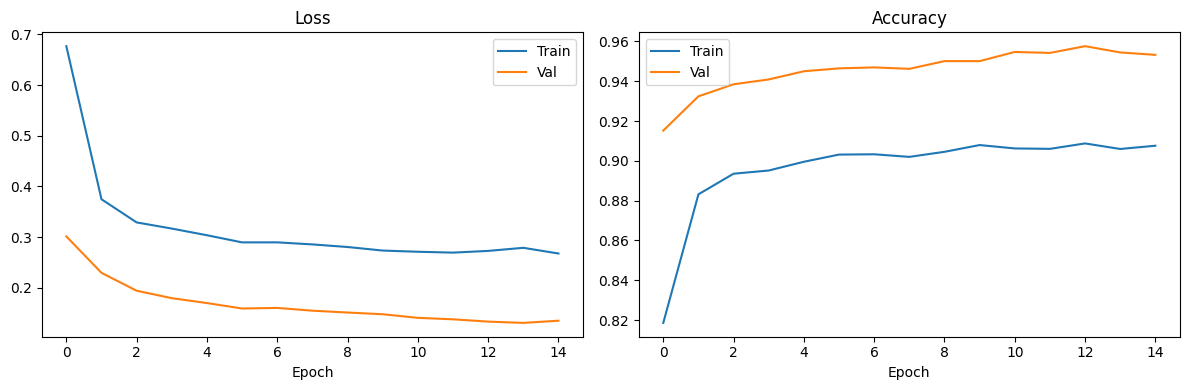

Final Train Acc : 0.9076
Final Val Acc   : 0.9532
Best Val Acc    : 0.9576


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

print(f"Final Train Acc : {history['train_acc'][-1]:.4f}")
print(f"Final Val Acc   : {history['val_acc'][-1]:.4f}")
print(f"Best Val Acc    : {best_val_acc:.4f}")

In [12]:
# Load best model
checkpoint = torch.load(MODEL_DIR / "best_model.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc:.4f}  ({test_acc*100:.2f}%)")

C:\Users\Pranj\AppData\Local\Temp\ipykernel_3988\1765840920.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_DIR / "best_model.pth", map_loc

Test Loss : 0.1496
Test Acc  : 0.9525  (95.25%)


In [ ]:
# Save the trained model
model.save("models/crop_disease_model.h5")
print("✅ Model saved!")